# 딜레이 이펙터

y[n] = x[n] + g * x[n-D]
- D: 딜레이 샘플 수
- g: 딜레이 신호의 게인
- x[n−D]: D만큼 지연된 입력
- x[n]: 원음(Dry)
- 딜레이 샘플 수 = 딜레이사간(ms) * Sample_rate / 1000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

class Delay:
    def __init__(self, delay_ms, sample_rate, gain):
        self.delay_ms = delay_ms
        self.sample_rate = sample_rate
        self.gain = gain

    def process(self, x):
        # 딜레이 샘플 수 계산
        D = int(self.delay_ms * self.sample_rate / 1000)
        
        # Numpy 슬라이싱을 이용한 최적화 (파이썬 for문 제거로 속도 대폭 향상)
        # 메아리가 잘리지 않게 원래 길이 + 딜레이 길이만큼 배열 생성
        y = np.zeros(len(x) + D, dtype=np.float32)
        
        # 1. 원래 소리 복사
        y[:len(x)] += x
        
        # 2. 딜레이(메아리) 소리 더하기
        y[D:len(x) + D] += self.gain * x
        
        return y


In [1]:
pip install matplotlib

  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl (4.8 MB)
Using cached pyparsing-3.3.2

In [4]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 9.2 MB/s  0:00:02 eta 0:00:01m
Note: you may need to restart the kernel to use updated packages.


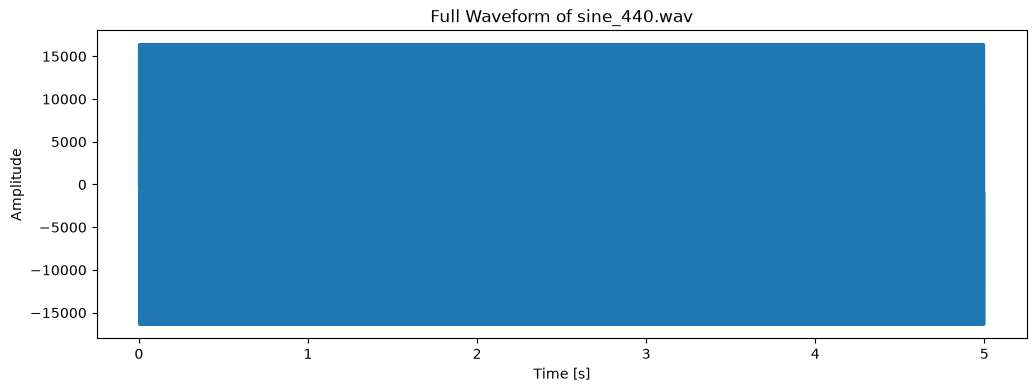

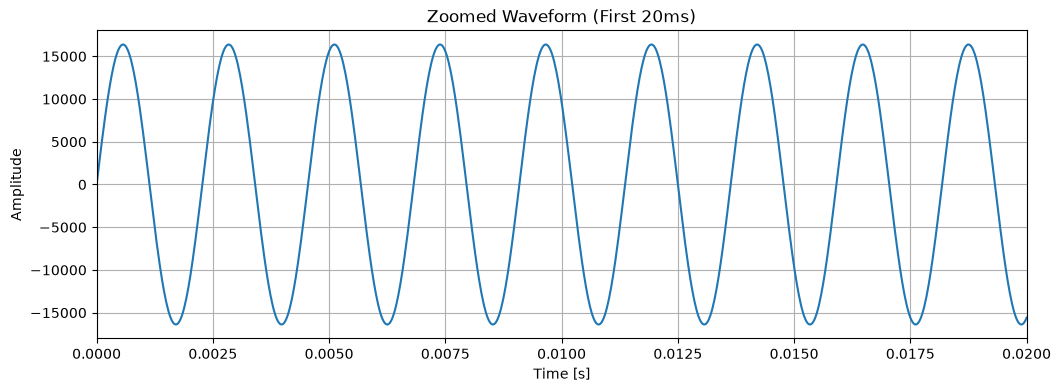

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1. WAV 파일 읽어오기
# sample_rate는 1초에 샘플이 몇 개 있는지(예: 44100), data는 실제 소리 데이터입니다.
sample_rate, data = wavfile.read('sine_440.wav')

# 2. X축(시간) 배열 만들기
# 전체 샘플 개수를 sample_rate로 나누면 오디오의 총 길이(초)가 나옵니다.
total_time = len(data) / sample_rate
time = np.linspace(0., total_time, len(data))

# 3. 전체 파형 그래프 그리기
plt.figure(figsize=(12, 4))
plt.plot(time, data)
plt.title("Full Waveform of sine_440.wav")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

# 4. 특정 구간만 확대해서 보기 (처음 20ms 구간)
# 440Hz 사인파의 모양을 제대로 보려면 아주 짧은 시간만 잘라서 봐야 합니다.
plt.figure(figsize=(12, 4))
plt.plot(time, data)
plt.title("Zoomed Waveform (First 20ms)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.xlim(0, 0.02) # x축을 0초에서 0.02초(20ms) 사이로 제한
plt.grid(True)    # 보기 편하게 격자 추가
plt.show()

딜레이가 적용된 파일이 저장되었습니다: sine_440_delayed.wav


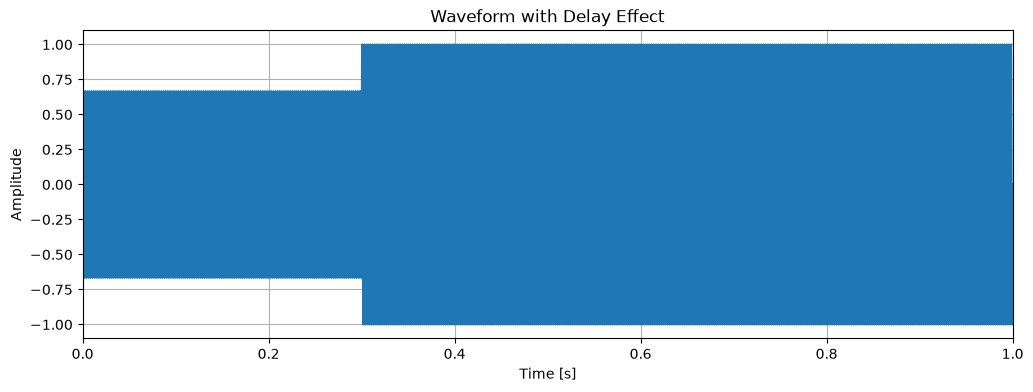

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1. 파일 읽기 및 실수형(float) 변환
sample_rate, data = wavfile.read('sine_440.wav')

# 만약 스테레오(2채널) 파일이라면 계산을 쉽게 하기 위해 왼쪽(0번) 채널만 가져옵니다.
if len(data.shape) > 1:
    data = data[:, 0]

# 소리가 겹치면 값이 커지므로, 계산을 위해 정수를 실수(float)로 변환합니다.
data = data.astype(np.float32)

# 2. 딜레이(메아리) 핵심 설정
delay_time_sec = 0.3  # 메아리가 0.3초 뒤에 나오도록 설정
decay = 0.5           # 메아리의 볼륨은 원본의 절반(0.5)으로 설정

# 시간(초)을 컴퓨터가 이해할 수 있는 배열의 칸 수(샘플 수)로 변환
delay_samples = int(sample_rate * delay_time_sec)

# 3. 새로운 빈 도화지(배열) 만들기
# 끝부분에 메아리가 잘리지 않도록 (원본 길이 + 딜레이 길이)만큼 넉넉하게 만듭니다.
output_data = np.zeros(len(data) + delay_samples, dtype=np.float32)

# 4. 🎵 딜레이 적용 (이 부분이 핵심!)
# 첫 번째: 원래 소리를 그대로 넣습니다. (0초부터 끝까지)
output_data[:len(data)] += data

# 두 번째: 메아리 소리를 더합니다. (0.3초 뒤부터 시작해서 작아진 소리를 더함)
output_data[delay_samples : len(data) + delay_samples] += (data * decay)

# 5. 소리 정규화 (선택 사항이지만 권장)
# 소리를 더하다 보면 최대 음량 허용치를 넘어가서 소리가 깨질 수 있습니다(Clipping).
# 가장 큰 소리를 기준으로 전체 볼륨을 안전하게 줄여줍니다.
max_amp = np.max(np.abs(output_data))
if max_amp > 0:
    output_data = output_data / max_amp

# 새로운 wav 파일로 저장해서 직접 들어보기!
# 저장하기 전에 다시 오디오 포맷(int16)으로 바꿔줍니다.
wavfile.write('sine_440_delayed.wav', sample_rate, np.int16(output_data * 32767))
print("딜레이가 적용된 파일이 저장되었습니다: sine_440_delayed.wav")

# 6. 파형 그려서 확인해 보기
time = np.linspace(0., len(output_data) / sample_rate, len(output_data))

plt.figure(figsize=(12, 4))
plt.plot(time, output_data)
plt.title("Waveform with Delay Effect")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.xlim(0, 1.0) # 0초 ~ 1초까지만 확인
plt.grid(True)
plt.show()


In [ ]:
# 1. 파일 읽기 및 실수형(float) 변환
sample_rate, data = wavfile.read('sine_440.wav')
if len(data.shape) > 1:
    data = data[:, 0]
data = data.astype(np.float32)

# 2. Delay 객체 생성 및 적용 (300ms, gain 0.5)
my_delay = Delay(delay_ms=300, sample_rate=sample_rate, gain=0.5)
output_data = my_delay.process(data)

# 3. 정규화 및 저장
max_amp = np.max(np.abs(output_data))
if max_amp > 0:
    output_data = output_data / max_amp

wavfile.write('sine_440_optimized_delay.wav', sample_rate, np.int16(output_data * 32767))
print('최적화된 딜레이 클래스로 적용 완료!')

# 4. 파형 그려서 확인
time = np.linspace(0., len(output_data) / sample_rate, len(output_data))
plt.figure(figsize=(12, 4))
plt.plot(time, output_data)
plt.title('Waveform with Optimized Delay')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 1.0)
plt.grid(True)
plt.show()
